# Exploratory Data Analysis (EDA) – Olist E-Commerce Dataset

This notebook explores the cleaned master dataset to uncover patterns, trends, and business insights.

Key goals:
- Understand distribution of numerical and categorical variables
- Analyze revenue trends
- Identify delivery performance insights
- Answer business questions using SQL-style analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_master_olist_dataset.csv")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,...,delivery_days,estimated_delivery_days,delivery_delay,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,8.0,15,-7.0,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,13.0,19,-6.0,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,9.0,26,-17.0,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,...,13.0,26,-13.0,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,...,2.0,12,-10.0,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62


In [3]:
df.shape

(112650, 22)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   customer_id                    112650 non-null  object 
 2   order_status                   112650 non-null  object 
 3   order_purchase_timestamp       112650 non-null  object 
 4   order_approved_at              112635 non-null  object 
 5   order_delivered_carrier_date   111456 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  112650 non-null  object 
 8   purchase_year                  112650 non-null  int64  
 9   purchase_month                 112650 non-null  int64  
 10  purchase_day                   112650 non-null  int64  
 11  purchase_weekday               112650 non-null  object 
 12  delivery_days                 

In [5]:
df.describe()

,purchase_year,purchase_month,purchase_day,delivery_days,estimated_delivery_days,delivery_delay,order_item_id,price,freight_value,total_revenue
count,112650.000000,112650.000000,112650.000000,110196.000000,112650.000000,110196.000000,112650.000000,112650.000000,112650.000000,112650.000000
mean,2017.541909,6.026835,15.558331,12.007723,23.470484,-11.433446,1.197834,120.653739,19.990320,140.644059
std,0.504792,3.232541,8.664745,9.451455,8.884872,10.170284,0.705124,183.633928,15.806405,190.724394
min,2016.000000,1.000000,1.000000,0.000000,2.000000,-146.000000,1.000000,0.850000,0.000000,6.080000
25%,2017.000000,3.000000,8.000000,6.000000,18.000000,-17.000000,1.000000,39.900000,13.080000,55.220000
50%,2018.000000,6.000000,16.000000,10.000000,23.000000,-12.000000,1.000000,74.990000,16.260000,92.320000
75%,2018.000000,8.000000,23.000000,15.000000,28.000000,-7.000000,1.000000,134.900000,21.150000,157.937500
max,2018.000000,12.000000,31.000000,209.000000,155.000000,189.000000,21.000000,6735.000000,409.680000,6929.310000


## Univariate Analysis

In this section we explore the distribution of key variables such as price, freight cost, and order status to understand their behavior.

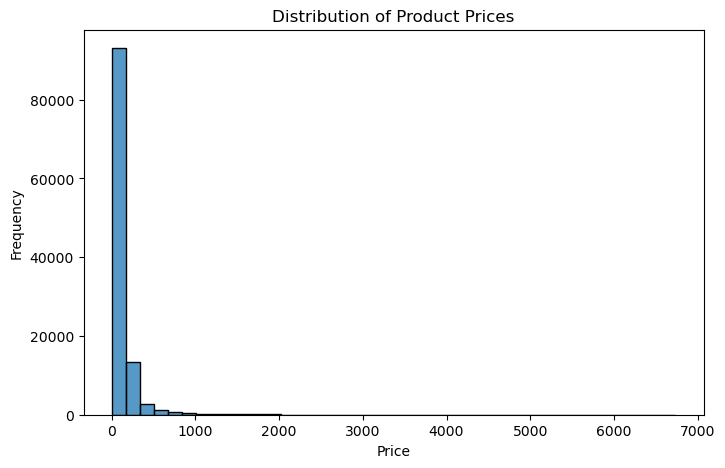

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=40)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

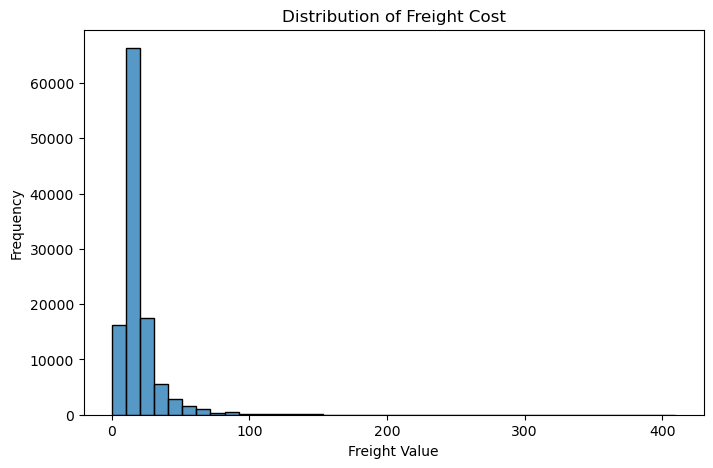

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['freight_value'], bins=40)
plt.title("Distribution of Freight Cost")
plt.xlabel("Freight Value")
plt.ylabel("Frequency")
plt.show()

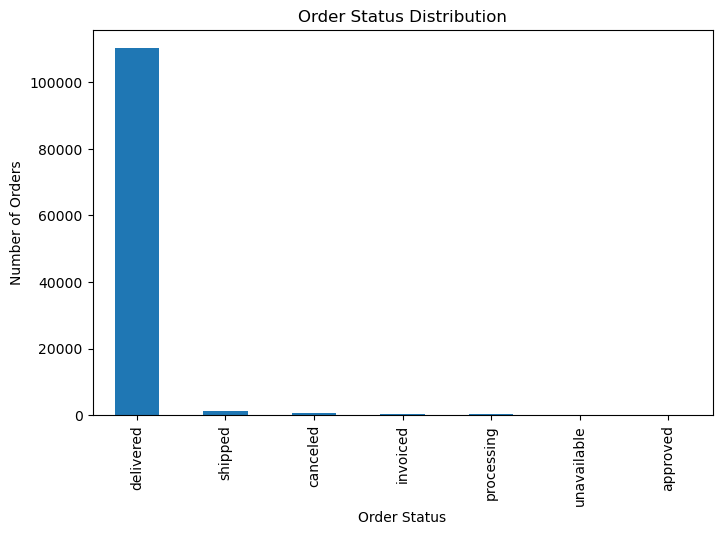

In [8]:
plt.figure(figsize=(8,5))
df['order_status'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.show()

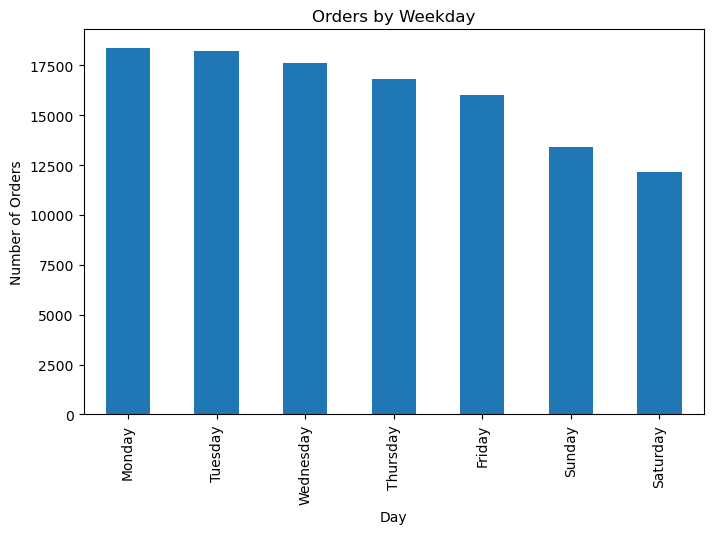

In [9]:
plt.figure(figsize=(8,5))
df['purchase_weekday'].value_counts().plot(kind='bar')
plt.title("Orders by Weekday")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.show()

## Business Questions & Insights

In this section we answer key business questions using aggregation and filtering techniques similar to SQL queries.

In [10]:
top_products = df.groupby('product_id')['total_revenue'] \
                 .sum() \
                 .sort_values(ascending=False) \
                 .head(10)

top_products

product_id
bb50f2e236e5eea0100680137654686c    67606.10
d1c427060a0f73f6b889a5c7c61f2ac4    60976.03
6cdd53843498f92890544667809f1595    59093.99
99a4788cb24856965c36a24e339b6058    51071.60
d6160fb7873f184099d9bc95e30376af    50326.18
3dd2a17168ec895c781a9191c1e95ad7    48212.22
aca2eb7d00ea1a7b8ebd4e68314663af    44820.76
5f504b3a1c75b73d6151be81eb05bdc9    41725.81
25c38557cf793876c5abdd5931f922db    40311.95
53b36df67ebb7c41585e8d54d6772e08    39957.93
Name: total_revenue, dtype: float64

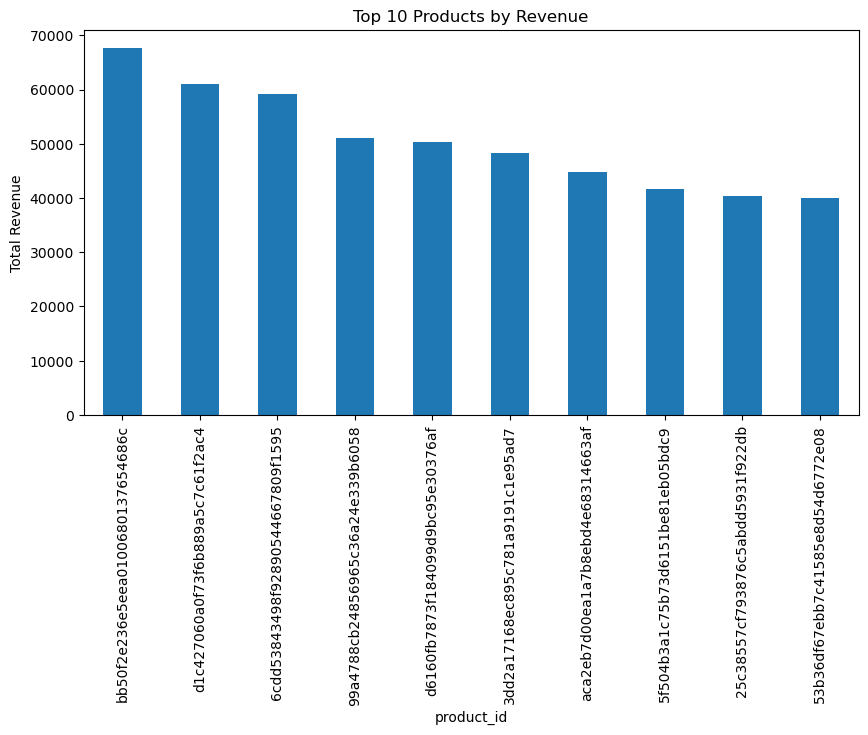

In [11]:
top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Products by Revenue")
plt.ylabel("Total Revenue")
plt.show()

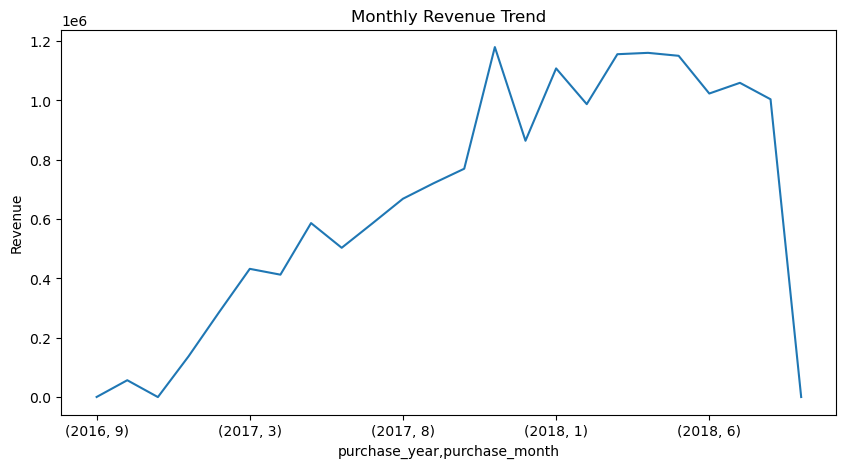

In [12]:
monthly_revenue = df.groupby(['purchase_year','purchase_month'])['total_revenue'].sum()

monthly_revenue.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

In [13]:
avg_delivery = df['delivery_days'].mean()
print("Average delivery time:", round(avg_delivery,2), "days")

Average delivery time: 12.01 days


In [14]:
top_sellers = df.groupby('seller_id')['total_revenue'] \
                .sum() \
                .sort_values(ascending=False) \
                .head(10)

top_sellers

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    249640.70
7c67e1448b00f6e969d365cea6b010ab    239536.44
53243585a1d6dc2643021fd1853d8905    235856.68
4a3ca9315b744ce9f8e9374361493884    235539.96
fa1c13f2614d7b5c4749cbc52fecda94    204084.73
da8622b14eb17ae2831f4ac5b9dab84a    185192.32
7e93a43ef30c4f03f38b393420bc753a    182754.05
1025f0e2d44d7041d6cf58b6550e0bfa    172860.69
7a67c85e85bb2ce8582c35f2203ad736    162648.38
955fee9216a65b617aa5c0531780ce60    160602.68
Name: total_revenue, dtype: float64

In [15]:
weekday_orders = df['purchase_weekday'].value_counts()

weekday_orders

purchase_weekday
Monday       18393
Tuesday      18237
Wednesday    17600
Thursday     16797
Friday       16039
Sunday       13416
Saturday     12168
Name: count, dtype: int64

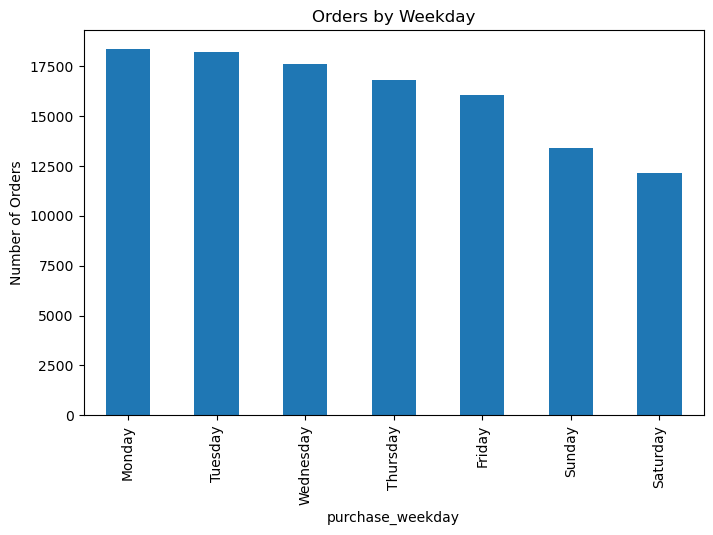

In [16]:
weekday_orders.plot(kind='bar', figsize=(8,5))
plt.title("Orders by Weekday")
plt.ylabel("Number of Orders")
plt.show()

## Multivariate Analysis

Here we analyze relationships between multiple variables such as price, freight value, and delivery performance.

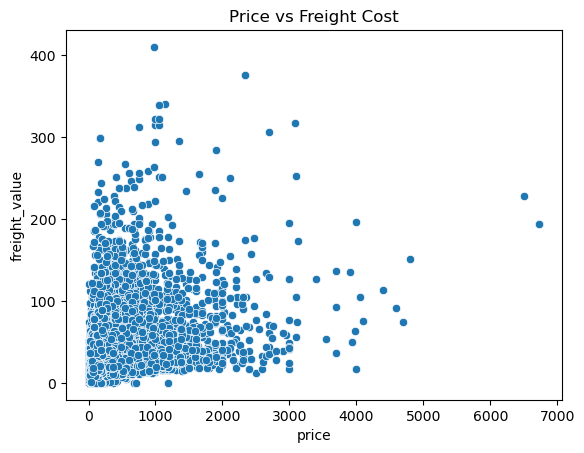

In [17]:
sns.scatterplot(x='price', y='freight_value', data=df)
plt.title("Price vs Freight Cost")
plt.show()

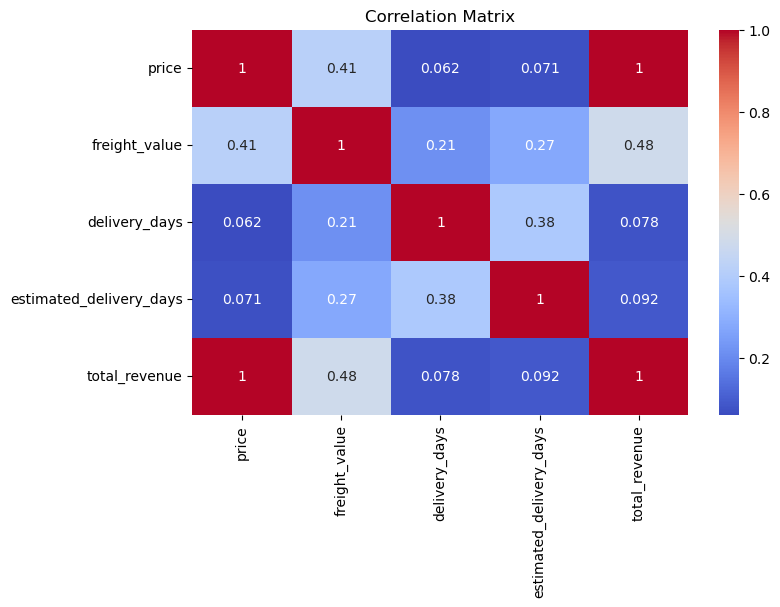

In [18]:
corr = df[['price','freight_value','delivery_days','estimated_delivery_days','total_revenue']].corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Revenue Trend Over Time

Understanding how revenue changes over time helps identify seasonal patterns and growth trends.

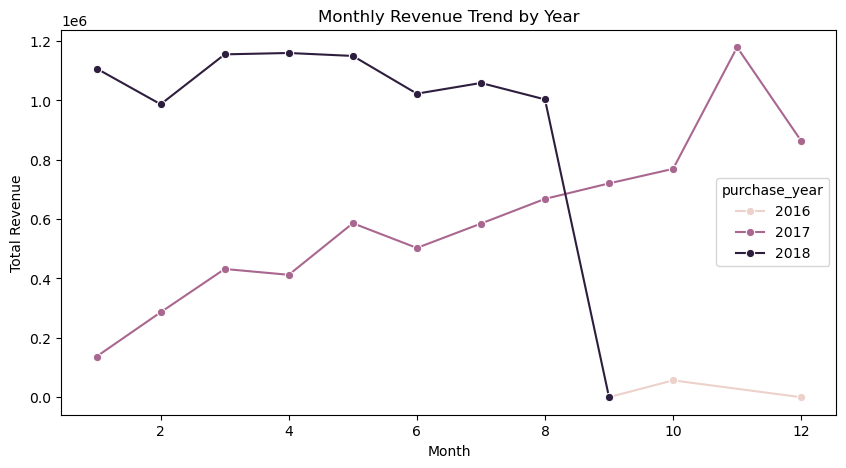

In [19]:
monthly_revenue = df.groupby(['purchase_year','purchase_month'])['total_revenue'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_revenue, x='purchase_month', y='total_revenue', hue='purchase_year', marker='o')

plt.title("Monthly Revenue Trend by Year")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

## Delivery Delay Analysis

We analyze whether deliveries are happening before or after the estimated delivery date.

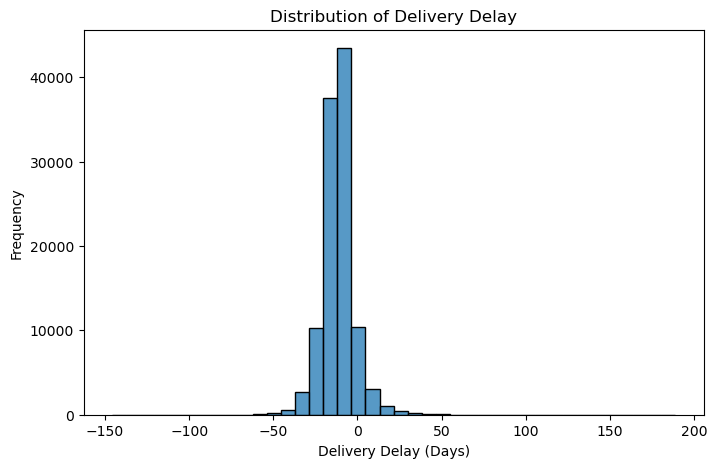

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['delivery_delay'], bins=40)

plt.title("Distribution of Delivery Delay")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Frequency")
plt.show()

In [21]:
late_orders = (df['delivery_delay'] > 0).sum()
total_orders = len(df)

print("Late delivery percentage:", round(late_orders/total_orders*100,2), "%")

Late delivery percentage: 7.23 %


## Revenue Distribution

This analysis helps understand how revenue is distributed across transactions.

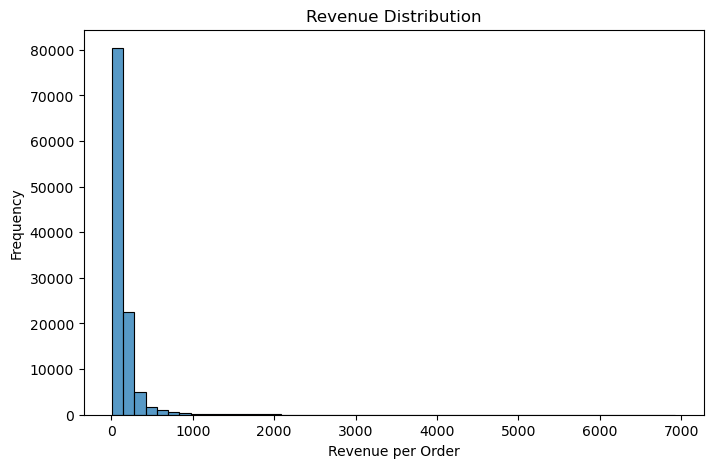

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_revenue'], bins=50)

plt.title("Revenue Distribution")
plt.xlabel("Revenue per Order")
plt.ylabel("Frequency")
plt.show()

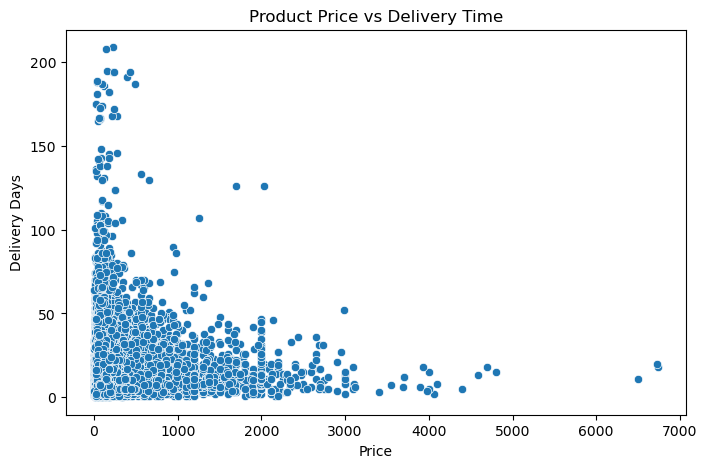

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='price', y='delivery_days')

plt.title("Product Price vs Delivery Time")
plt.xlabel("Price")
plt.ylabel("Delivery Days")
plt.show()

## Final Insights

• Majority of orders fall in the low to mid price range  
• Revenue trends show variation across months indicating possible seasonal demand  
• Freight cost generally increases with product price  
• Most deliveries occur before or close to the estimated delivery date  
• A small number of products contribute significantly to total revenue